# 9주차 실습 — 인공지능의 혁신, 트랜스포머 **[문제]**

**생성형 인공지능 / 학부 4학년 실습**

---

## 실습 목표

강의에서 다룬 다음 개념들을 **직접 코드로 구현**하면서 이해합니다.

| 강의 소주제 | 실습 문제 |
|---|---|
| 언어 모델의 개념 / 통계적 언어 모델 | 문제 1 |
| 트랜스포머의 어텐션 메커니즘과 계산 | 문제 2 |
| "각각의 어텐션은 계산적으로 독립 → 병렬 처리 용이" | 문제 3 |
| BERT(인코더·양방향) vs GPT(디코더·단방향) | 문제 4 |
| 언어 모델의 확률 분포와 텍스트 생성 | 문제 5 |
| 사전 학습 목적함수 (MLM vs CLM) | 문제 6 |
| 거대 언어 모델의 규모 / 프롬프트 엔지니어링 | 문제 7 (보너스) |

## 실습 규칙

- 사용 라이브러리는 **NumPy와 Matplotlib뿐**입니다. (딥러닝 프레임워크·사전학습 모델 다운로드 없음 → Colab에서 즉시 실행)
- 각 문제의 `### TODO` 부분만 채우면 됩니다.
- 문제마다 **검증(Check) 셀**이 있습니다. `✅ PASS`가 뜨면 정답입니다.
- 서술형 답안은 마지막 셀의 문자열 변수에 작성하세요.

> ⏱️ 예상 소요 시간: 2~3시간


---
## 0. 환경 설정

아래 셀을 먼저 실행하세요. (한글 폰트가 없으면 그래프 축 이름은 자동으로 로마자로 표시됩니다.)


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

# --- 한글 폰트 설정 ---
# Colab에서 그래프의 한글이 네모(□)로 보이면 아래 두 줄의 주석을 풀고 실행한 뒤,
# [런타임] > [세션 다시 시작] 후 이 셀을 다시 실행하세요.
# !apt-get -qq install -y fonts-nanum > /dev/null
# !fc-cache -fv > /dev/null && rm -rf ~/.cache/matplotlib
HAS_KO_FONT = False
try:
    import matplotlib.font_manager as fm
    for name in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic"]:
        if any(f.name == name for f in fm.fontManager.ttflist):
            matplotlib.rc("font", family=name)
            HAS_KO_FONT = True
            break
except Exception:
    pass
matplotlib.rcParams["axes.unicode_minus"] = False

# 한글 폰트가 없을 때 그래프 라벨용 로마자 대체 표기
ROMAN = {"나는": "naneun", "배가": "baega", "고팠다": "gopatda", "그래서": "geuraeseo",
         "사과를": "sagwareul", "먹었다": "meogeotda", "김치를": "kimchireul",
         "담그려": "damgeuryeo", "한다": "handa", "깎았다": "kkakkatda",
         "잘랐다": "jallatda", "[MASK]": "[MASK]", "<s>": "<s>", "</s>": "</s>"}

def lab(tok):
    '''그래프 라벨용 토큰 표기'''
    return tok if HAS_KO_FONT else ROMAN.get(tok, tok)

print("NumPy", np.__version__, "| 한글 폰트:", "사용 가능" if HAS_KO_FONT else "없음(로마자 표기 사용)")

NumPy 2.5.2 | 한글 폰트: 사용 가능


---
# 문제 1. 언어 모델의 출발점 — 어휘 사전과 통계적 언어 모델

> 강의: *"언어 모델은 단어 시퀀스에 대한 확률 분포를 의미하는 것으로, 쉽게 설명하면 주어진 문장 뒤에 올 단어를 예측함"*
> 강의: *"통계적 언어 모델은 주어진 단어에 대해 다음 단어가 올 조건부 확률을 통계적으로 구하는 기법"*

강의의 예시 문장을 그대로 코퍼스로 사용합니다.

- "나는 배가 고팠다 그래서 사과를 **먹었다**"
- "나는 김치를 담그려 한다 그래서 사과를 **깎았다**"

같은 `"그래서 사과를"` 뒤에 오는 단어가 앞 문맥에 따라 달라진다는 점이 핵심입니다.

## 구현할 것
1. `build_vocab(corpus)` — 코퍼스에서 어휘 사전(`token2id`, `id2token`)을 만든다.
2. `ngram_counts(corpus, n)` — n-gram 빈도를 센다.
3. `cond_prob(context, next_token, counts, ctx_counts)` — 강의 슬라이드의 공식

$$P(w_n \mid w_1 \dots w_{n-1}) = \frac{\text{Count}(w_1 \dots w_{n-1} w_n)}{\text{Count}(w_1 \dots w_{n-1})}$$

4. 학습 데이터에 없는 문맥을 넣어 **희소성(sparsity) 문제**를 직접 확인한다.


In [2]:
CORPUS = [
    "나는 배가 고팠다 그래서 사과를 먹었다",
    "나는 김치를 담그려 한다 그래서 사과를 깎았다",
    "나는 배가 고팠다 그래서 빵을 먹었다",
    "나는 김치를 담그려 한다 그래서 무를 깎았다",
    "나는 배가 고팠다 그래서 사과를 먹었다",
]

def tokenize(sent):
    return sent.split()

for s in CORPUS:
    print(tokenize(s))

['나는', '배가', '고팠다', '그래서', '사과를', '먹었다']
['나는', '김치를', '담그려', '한다', '그래서', '사과를', '깎았다']
['나는', '배가', '고팠다', '그래서', '빵을', '먹었다']
['나는', '김치를', '담그려', '한다', '그래서', '무를', '깎았다']
['나는', '배가', '고팠다', '그래서', '사과를', '먹었다']


In [3]:
from collections import Counter, defaultdict

def build_vocab(corpus, specials=("<s>", "</s>", "[MASK]")):
    '''코퍼스 -> (token2id, id2token)'''
    id2token = list(specials)
    seen = set(id2token)
    for sentence in corpus:
        for token in tokenize(sentence):
            if token not in seen:
                seen.add(token)
                id2token.append(token)
    token2id = {token: index for index, token in enumerate(id2token)}
    return token2id, id2token


def ngram_counts(corpus, n):
    '''길이 n인 n-gram 튜플의 빈도 Counter를 반환.'''
    cnt = Counter()
    for sentence in corpus:
        tokens = tokenize(sentence)
        cnt.update(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return cnt


def cond_prob(context, next_token, ngram_cnt, ctx_cnt):
    '''P(next_token | context).'''
    denominator = ctx_cnt[tuple(context)]
    if denominator == 0:
        return 0.0
    return ngram_cnt[tuple(context) + (next_token,)] / denominator


token2id, id2token = build_vocab(CORPUS)
print("어휘 크기 V =", len(id2token))
print(id2token)


어휘 크기 V = 15
['<s>', '</s>', '[MASK]', '나는', '배가', '고팠다', '그래서', '사과를', '먹었다', '김치를', '담그려', '한다', '깎았다', '빵을', '무를']


In [4]:
# ---- Check 1 ----
assert id2token[:3] == ["<s>", "</s>", "[MASK]"], "special 토큰이 앞에 와야 합니다"
assert len(id2token) == 15, f"어휘 크기가 15여야 합니다 (현재 {len(id2token)})"
assert token2id["나는"] == 3

bi = ngram_counts(CORPUS, 2)
tri = ngram_counts(CORPUS, 3)
uni = ngram_counts(CORPUS, 1)
assert bi[("그래서", "사과를")] == 3, bi[("그래서", "사과를")]
assert tri[("고팠다", "그래서", "사과를")] == 2

# 강의 슬라이드의 바로 그 계산: P(먹었다 | 그래서 사과를) = 2/3, P(깎았다 | ...) = 1/3
p1 = cond_prob(("그래서", "사과를"), "먹었다", tri, bi)
p2 = cond_prob(("그래서", "사과를"), "깎았다", tri, bi)
assert abs(p1 - 2/3) < 1e-9, p1
assert abs(p2 - 1/3) < 1e-9, p2
print(f"P(먹었다 | 그래서 사과를) = {p1:.3f}")
print(f"P(깎았다 | 그래서 사과를) = {p2:.3f}")
print("✅ PASS — 문제 1-1 ~ 1-3")

P(먹었다 | 그래서 사과를) = 0.667
P(깎았다 | 그래서 사과를) = 0.333
✅ PASS — 문제 1-1 ~ 1-3


### 1-4. 희소성(sparsity) 문제 관찰

`bigram` 문맥 하나만 쓰면 앞 상황("배가 고팠다" vs "김치를 담그려 한다")을 구분하지 못합니다.
문맥을 4-gram으로 늘리면 구분은 되지만, **학습 데이터에 없는 문맥은 확률이 전부 0**이 됩니다.
아래 셀을 실행해 두 현상을 모두 확인하세요.


In [ ]:
four = ngram_counts(CORPUS, 4)
three = ngram_counts(CORPUS, 3)

def next_dist(context, big_cnt, small_cnt, vocab):
    return {w: cond_prob(context, w, big_cnt, small_cnt) for w in vocab
            if cond_prob(context, w, big_cnt, small_cnt) > 0}

print("[문맥 2개 단어] 그래서 사과를 ->", next_dist(("그래서","사과를"), tri, bi, id2token))
print("[문맥 3개 단어] 고팠다 그래서 사과를 ->", next_dist(("고팠다","그래서","사과를"), four, three, id2token))
print("[문맥 3개 단어] 한다 그래서 사과를 ->", next_dist(("한다","그래서","사과를"), four, three, id2token))
print()
print("[미등장 문맥] 나는 라면을 끓였다 ->", next_dist(("나는","라면을","끓였다"), four, three, id2token))
print("→ 확률 분포가 비어 있음 = 통계적 언어 모델의 희소성 문제")

---
# 문제 2. Scaled Dot-Product Attention 직접 구현

> 강의: *"트랜스포머의 어텐션 메커니즘 연산은 행렬곱이며"*
> 강의: *"트랜스포머는 벡터로 표현된 단어를 어텐션 행렬과의 곱셈을 통해 새로운 관점으로 부여"*

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

## 구현할 것
1. `softmax(x, axis)` — **수치적으로 안정한** 소프트맥스 (최댓값을 빼고 지수화)
2. `scaled_dot_product_attention(Q, K, V, mask)` — 위 수식. `mask`는 boolean 배열이며 `True`인 위치만 **참조 허용**, `False`는 매우 작은 값(-1e9)으로 만들어 확률을 0에 가깝게 만든다.

### 왜 $\sqrt{d_k}$ 로 나눌까?
$d_k$가 커질수록 $QK^\top$의 분산이 커져 softmax가 한 곳으로 몰리고(=포화), 기울기가 사라집니다. 문제 2-3에서 직접 확인합니다.


In [5]:
def softmax(x, axis=-1):
    '''수치적으로 안정한 softmax.'''
    x = np.asarray(x)
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    '''Q:(..., Lq, d_k), K:(..., Lk, d_k), V:(..., Lk, d_v)'''
    depth = Q.shape[-1]
    scores = np.matmul(Q, np.swapaxes(K, -1, -2)) / np.sqrt(depth)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores, axis=-1)
    output = np.matmul(weights, V)
    return output, weights


In [6]:
# ---- Check 2 ----
# (1) softmax 기본 성질
z = np.array([[1.0, 2.0, 3.0], [10.0, 10.0, 10.0]])
s = softmax(z)
assert np.allclose(s.sum(axis=-1), 1.0), "각 행의 합이 1이어야 합니다"
assert np.allclose(s[1], [1/3, 1/3, 1/3]), "동일한 값이면 균등분포여야 합니다"
# (2) 수치 안정성: 큰 값이 들어와도 nan이 나오면 안 됨
big = np.array([[1000.0, 1001.0, 1002.0]])
assert np.isfinite(softmax(big)).all(), "오버플로 발생! max를 빼주세요"

# (3) 어텐션
L, d_k, d_v = 4, 8, 5
Q = np.random.randn(L, d_k); K = np.random.randn(L, d_k); V = np.random.randn(L, d_v)
out, w = scaled_dot_product_attention(Q, K, V)
assert out.shape == (L, d_v) and w.shape == (L, L)
assert np.allclose(w.sum(axis=-1), 1.0), "어텐션 가중치의 각 행 합은 1"

# (4) mask 동작 확인
m = np.ones((L, L), dtype=bool); m[:, 0] = False
_, wm = scaled_dot_product_attention(Q, K, V, mask=m)
assert np.allclose(wm[:, 0], 0.0, atol=1e-6), "마스킹된 위치의 가중치는 0에 가까워야 합니다"

# (5) V의 볼록결합인지: 모든 Q가 동일하면 출력 행도 모두 동일
Qs = np.ones((3, d_k))
o2, _ = scaled_dot_product_attention(Qs, K, V)
assert np.allclose(o2[0], o2[1]) and np.allclose(o2[1], o2[2])
print("✅ PASS — 문제 2-1, 2-2")

✅ PASS — 문제 2-1, 2-2


### 2-3. $\sqrt{d_k}$ 스케일링의 효과 확인

아래 셀은 $d_k$를 키우면서 **스케일링을 했을 때/안 했을 때** 어텐션 분포의 엔트로피를 비교합니다.
엔트로피가 0에 가까워진다 = 한 토큰에만 100% 몰린다 = 기울기가 거의 흐르지 않는다.


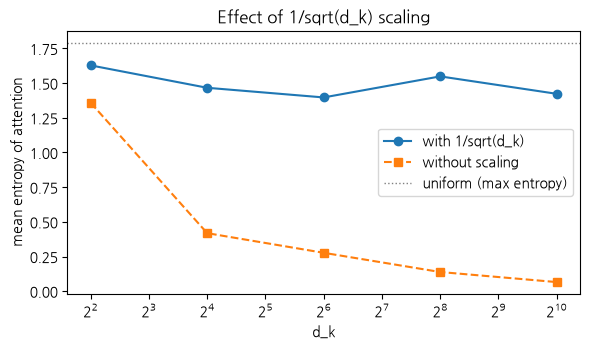

scaled : [1.628, 1.466, 1.397, 1.549, 1.423]
raw    : [1.358, 0.419, 0.277, 0.138, 0.066]


In [7]:
def entropy(p):
    return float(-(p * np.log(p + 1e-12)).sum(axis=-1).mean())

dks = [4, 16, 64, 256, 1024]
ent_scaled, ent_raw = [], []
for dk in dks:
    Q = np.random.randn(6, dk); K = np.random.randn(6, dk); V = np.random.randn(6, 3)
    _, w_s = scaled_dot_product_attention(Q, K, V)              # 1/sqrt(dk) 적용
    w_r = softmax(Q @ K.T)                                      # 스케일링 없음
    ent_scaled.append(entropy(w_s)); ent_raw.append(entropy(w_r))

plt.figure(figsize=(6, 3.6))
plt.plot(dks, ent_scaled, "o-", label="with 1/sqrt(d_k)")
plt.plot(dks, ent_raw, "s--", label="without scaling")
plt.axhline(np.log(6), color="gray", lw=1, ls=":", label="uniform (max entropy)")
plt.xscale("log", base=2); plt.xlabel("d_k"); plt.ylabel("mean entropy of attention")
plt.title("Effect of 1/sqrt(d_k) scaling"); plt.legend(); plt.tight_layout(); plt.show()

print("scaled :", [round(e, 3) for e in ent_scaled])
print("raw    :", [round(e, 3) for e in ent_raw])

---
# 문제 3. 멀티헤드 어텐션 — "각각의 어텐션은 계산적으로 독립"

> 강의: *"각각의 어텐션 계산은 서로 독립 → 병렬 처리가 용이"*, *"계산된 어텐션은 하나로 취합"*
> 강의 그림: 어텐션1(색깔 관계), 어텐션2(과일 관계), 어텐션3(과일–색깔 관계) → 하나의 인코더/디코더 출력

$$\text{MHA}(X) = \big[\,\text{head}_1;\dots;\text{head}_h\,\big]W^O,\quad
\text{head}_i = \text{Attention}(XW^Q_i,\ XW^K_i,\ XW^V_i)$$

## 구현할 것
1. `split_heads(X, h)` : `(L, d_model)` → `(h, L, d_model/h)`
2. `merge_heads(X)` : `(h, L, d_head)` → `(L, d_model)`  (split의 정확한 역연산)
3. `multi_head_attention(...)` : 위 수식
4. **검증 3-4**: "for문으로 헤드를 하나씩 계산한 결과"와 "배치 행렬곱으로 한 번에 계산한 결과"가 **완전히 같음**을 확인 → 이것이 곧 *독립·병렬 처리 가능*의 의미


In [8]:
def split_heads(X, h):
    '''(L, d_model) -> (h, L, d_head)'''
    L, d_model = X.shape
    assert d_model % h == 0, "d_model은 head 수로 나누어떨어져야 합니다"
    return X.reshape(L, h, d_model // h).transpose(1, 0, 2)


def merge_heads(X):
    '''(h, L, d_head) -> (L, d_model)'''
    h, L, d_head = X.shape
    return X.transpose(1, 0, 2).reshape(L, h * d_head)


def multi_head_attention(X, Wq, Wk, Wv, Wo, h, mask=None):
    '''X:(L, d_model), W*:(d_model, d_model)'''
    Q = split_heads(X @ Wq, h)
    K = split_heads(X @ Wk, h)
    V = split_heads(X @ Wv, h)
    attended, weights = scaled_dot_product_attention(Q, K, V, mask=mask)
    out = merge_heads(attended) @ Wo
    return out, weights


In [9]:
# ---- Check 3 ----
L, d_model, h = 6, 12, 3
X  = np.random.randn(L, d_model)
Wq, Wk, Wv, Wo = (np.random.randn(d_model, d_model) / np.sqrt(d_model) for _ in range(4))

# (1) split/merge가 서로의 역연산인지
assert split_heads(X, h).shape == (h, L, d_model // h)
assert np.allclose(merge_heads(split_heads(X, h)), X), "merge(split(X)) == X 가 성립해야 합니다"

out, w = multi_head_attention(X, Wq, Wk, Wv, Wo, h)
assert out.shape == (L, d_model), out.shape
assert w.shape == (h, L, L), w.shape
assert np.allclose(w.sum(axis=-1), 1.0)

# (2) 3-4 핵심 검증: 헤드를 for문으로 하나씩 계산해도 결과가 동일한가?
d_head = d_model // h
heads_seq = []
for i in range(h):
    sl = slice(i * d_head, (i + 1) * d_head)
    Qi, Ki, Vi = X @ Wq[:, sl], X @ Wk[:, sl], X @ Wv[:, sl]
    hi, _ = scaled_dot_product_attention(Qi, Ki, Vi)
    heads_seq.append(hi)
out_seq = np.concatenate(heads_seq, axis=-1) @ Wo

assert np.allclose(out, out_seq, atol=1e-10), "헤드별 순차 계산과 결과가 달라졌습니다"
print("최대 오차:", np.abs(out - out_seq).max())
print("✅ PASS — 문제 3-1 ~ 3-3")
print("→ 순차 계산 == 병렬(배치) 계산. 각 헤드가 서로 독립이므로 GPU에서 한 번에 처리할 수 있습니다.")

최대 오차: 7.771561172376096e-16
✅ PASS — 문제 3-1 ~ 3-3
→ 순차 계산 == 병렬(배치) 계산. 각 헤드가 서로 독립이므로 GPU에서 한 번에 처리할 수 있습니다.


---
# 문제 4. BERT vs GPT — 마스킹으로 갈리는 두 구조

> 강의: *"BERT는 트랜스포머 **인코더**를 활용하여 주어진 시퀀스의 빈칸(Mask)을 예측하는 방식"*
> 강의: *"GPT는 트랜스포머 **디코더**를 활용하여 주어진 시퀀스의 **다음 단어**를 예측하는 방식"*

두 모델의 어텐션 계산은 **완전히 동일**하고, 차이는 **어떤 위치를 볼 수 있게 허용하느냐(mask)** 뿐입니다.

- BERT(인코더): 모든 토큰이 **양방향**으로 서로를 참조 → `mask` 전부 True
- GPT(디코더): $i$번째 토큰은 $j \le i$ 인 토큰만 참조 (**causal / look-ahead mask**)

## 구현할 것
1. `bidirectional_mask(L)` — BERT용
2. `causal_mask(L)` — GPT용 (하삼각행렬)
3. `padding_mask(lengths, L)` — 배치에서 길이가 다른 문장의 `<pad>` 위치를 가리는 마스크


In [10]:
def bidirectional_mask(L):
    '''(L, L) bool. 모든 위치 참조 허용.'''
    return np.ones((L, L), dtype=bool)


def causal_mask(L):
    '''(L, L) bool. i행은 j<=i 인 열만 True.'''
    return np.tril(np.ones((L, L), dtype=bool))


def padding_mask(lengths, L):
    '''lengths: 각 문장의 실제 길이 리스트 -> (B, 1, L) bool.'''
    lengths = np.asarray(lengths)
    return (np.arange(L)[None, :] < lengths[:, None])[:, None, :]


In [11]:
# ---- Check 4 ----
assert bidirectional_mask(4).all()
cm = causal_mask(4)
assert cm.dtype == np.bool_ and cm.shape == (4, 4)
assert cm[0].sum() == 1 and cm[3].sum() == 4, "i번째 행은 i+1개가 True여야 합니다"
assert not cm[1, 2], "미래 토큰을 보면 안 됩니다"
pm = padding_mask([3, 5, 1], 5)
assert pm.shape == (3, 1, 5)
assert pm[0, 0].tolist() == [True, True, True, False, False]
print("causal mask (GPT):\n", cm.astype(int))
print("✅ PASS — 문제 4-1 ~ 4-3")

causal mask (GPT):
 [[1 0 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 1]]
✅ PASS — 문제 4-1 ~ 4-3


### 4-4. 같은 문장, 다른 마스크 — 어텐션 가중치 비교

문장: `나는 사과를 먹었다 김치를 담갔다`

같은 $Q,K,V$에 마스크만 바꿔 넣고 어텐션 히트맵을 그려 보세요.
BERT는 오른쪽 위 영역이 살아있고, GPT는 완전히 0(하삼각)입니다.


In [ ]:
sent = ["나는", "사과를", "먹었다", "김치를", "담갔다"]
L = len(sent); d = 16
Xs = np.random.randn(L, d)
Wq_, Wk_, Wv_ = (np.random.randn(d, d) / np.sqrt(d) for _ in range(3))
Qs, Ks, Vs = Xs @ Wq_, Xs @ Wk_, Xs @ Wv_

_, w_bert = scaled_dot_product_attention(Qs, Ks, Vs, mask=bidirectional_mask(L))
_, w_gpt  = scaled_dot_product_attention(Qs, Ks, Vs, mask=causal_mask(L))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, W, title in zip(axes, [w_bert, w_gpt],
                        ["BERT (encoder, bidirectional)", "GPT (decoder, causal)"]):
    im = ax.imshow(W, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(L)); ax.set_xticklabels([lab(t) for t in sent], rotation=45, ha="right")
    ax.set_yticks(range(L)); ax.set_yticklabels([lab(t) for t in sent])
    ax.set_title(title); ax.set_xlabel("Key (참조 대상)"if HAS_KO_FONT else "Key (attended to)")
    ax.set_ylabel("Query" )
    for i in range(L):
        for j in range(L):
            ax.text(j, i, f"{W[i,j]:.2f}", ha="center", va="center",
                    color="w" if W[i, j] < 0.5 else "k", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

print("GPT 마스크에서 상삼각 합 =", w_gpt[np.triu_indices(L, k=1)].sum(), "(≈0 이어야 정상)")

---
# 문제 5. 언어 모델의 확률 분포와 텍스트 생성 (온도 / 그리디 / 샘플링)

> 강의 그림: `"나는 배가 고팠다. 그래서 사과를 ___"` → **먹었다 70% / 깎았다 28% / 만졌다 0.9% / …**
> 강의: *"생성된 단어를 입력으로"* (자기회귀 생성)

## 구현할 것
1. `apply_temperature(logits, T)` — $\text{softmax}(\text{logits}/T)$
2. `top_k_filter(probs, k)` — 확률 상위 k개만 남기고 나머지는 0으로 만든 뒤 **재정규화**
3. `generate(...)` — 문제 1의 통계적 언어 모델을 확률원으로 삼아 자기회귀적으로 문장을 생성
   - `greedy=True` : 항상 argmax
   - `greedy=False`: 온도·top-k를 적용한 확률 분포에서 샘플링


In [12]:
VOCAB = id2token
V = len(VOCAB)

def apply_temperature(logits, T=1.0):
    '''logits:(V,) -> 확률.'''
    if T <= 0:
        raise ValueError("temperature는 양수여야 합니다")
    return softmax(np.asarray(logits) / T)


def top_k_filter(probs, k):
    '''확률 상위 k개만 남기고 재정규화.'''
    probs = np.asarray(probs, dtype=float).copy()
    if k is None or k >= len(probs):
        total = probs.sum()
        return probs / total if total > 0 else np.ones_like(probs) / len(probs)
    k = max(1, int(k))
    indices = np.argpartition(-probs, k - 1)[:k]
    filtered = np.zeros_like(probs)
    filtered[indices] = probs[indices]
    return filtered / filtered.sum()


def lm_logits(context, big_cnt, small_cnt, vocab):
    '''통계적 LM의 조건부 확률을 logit(=log p)으로 변환.'''
    p = np.array([cond_prob(context, w, big_cnt, small_cnt) for w in vocab], dtype=float)
    if p.sum() == 0:
        p = np.ones(len(vocab)) / len(vocab)
    return np.log(p + 1e-12)


def generate(start_tokens, n_steps=5, T=1.0, k=None, greedy=False, seed=0):
    '''start_tokens에서 시작해 n_steps개 단어를 이어 붙인다.'''
    rng = np.random.default_rng(seed)
    toks = list(start_tokens)
    for _ in range(n_steps):
        ctx = tuple(toks[-2:])
        logits = lm_logits(ctx, tri, bi, VOCAB)
        probs = top_k_filter(apply_temperature(logits, T), k)
        if greedy:
            nxt = VOCAB[int(np.argmax(probs))]
        else:
            nxt = VOCAB[int(rng.choice(len(VOCAB), p=probs))]
        toks.append(nxt)
        if nxt == "</s>":
            break
    return toks


In [13]:
# ---- Check 5 ----
lg = np.array([2.0, 1.0, 0.0, -1.0])
p1 = apply_temperature(lg, 1.0)
p_cold = apply_temperature(lg, 0.1)
p_hot  = apply_temperature(lg, 10.0)
assert np.allclose(p1.sum(), 1) and np.allclose(p_cold.sum(), 1)
assert p_cold[0] > p1[0] > p_hot[0], "T가 작을수록 최댓값 확률이 커져야 합니다"
assert p_hot.std() < p1.std() < p_cold.std(), "T가 클수록 분포가 평평해야 합니다"
assert np.argmax(p_cold) == np.argmax(p1) == 0, "온도는 순위를 바꾸지 않습니다"

f = top_k_filter(np.array([0.4, 0.3, 0.2, 0.1]), 2)
assert np.allclose(f, [4/7, 3/7, 0, 0]), f
assert np.allclose(top_k_filter(np.array([0.4, 0.3, 0.2, 0.1]), 10).sum(), 1.0)

g = generate(["그래서", "사과를"], n_steps=1, greedy=True)
assert g[-1] == "먹었다", g
print("greedy          :", " ".join(generate(["나는", "배가"], n_steps=4, greedy=True)))
for sd in [1, 3, 5]:
    print(f"sampling(T=1.0, seed={sd}):",
          " ".join(generate(["나는", "배가"], n_steps=4, T=1.0, k=5, seed=sd)))
print("✅ PASS — 문제 5-1 ~ 5-3")

greedy          : 나는 배가 고팠다 그래서 사과를 먹었다
sampling(T=1.0, seed=1): 나는 배가 고팠다 그래서 사과를 깎았다
sampling(T=1.0, seed=3): 나는 배가 고팠다 그래서 빵을 먹었다
sampling(T=1.0, seed=5): 나는 배가 고팠다 그래서 사과를 먹었다
✅ PASS — 문제 5-1 ~ 5-3


### 5-4. 온도에 따른 확률 분포 시각화

강의 슬라이드의 `"나는 배가 고팠다 그래서 사과를 ___"` 상황을 재현합니다.


In [ ]:
ctx = ("그래서", "사과를")
base = lm_logits(ctx, tri, bi, VOCAB)
# 강의 예시처럼 다양성을 주기 위해 아주 약한 노이즈를 더한 '모델 출력' 가정
rng = np.random.default_rng(7)
base = base + rng.normal(0, 0.5, size=base.shape)

temps = [0.3, 1.0, 3.0]
fig, axes = plt.subplots(1, len(temps), figsize=(13, 3.6), sharey=True)
for ax, T in zip(axes, temps):
    p = apply_temperature(base, T)
    order = np.argsort(-p)[:6]
    ax.bar(range(len(order)), p[order], color="#2e8b74")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([lab(VOCAB[i]) for i in order], rotation=45, ha="right")
    ax.set_title(f"T = {T}   (entropy={-(p*np.log(p+1e-12)).sum():.2f})")
axes[0].set_ylabel("P(next word)")
plt.suptitle("Next-word distribution after '그래서 사과를'" if HAS_KO_FONT
             else "Next-word distribution after 'geuraeseo sagwareul'")
plt.tight_layout(); plt.show()

---
# 문제 6. 사전 학습 목적함수 — MLM(BERT) vs CLM(GPT)

> 강의: BERT = *"주어진 시퀀스의 빈칸(Mask)을 예측하는 방식으로 언어 모델을 학습"*
> 강의: GPT = *"주어진 시퀀스의 다음 단어를 예측하는 방식으로 언어 모델을 학습"*

같은 문장 하나로 두 가지 학습 예제를 만들어 보고, 손실(cross entropy)을 계산합니다.

## 구현할 것
1. `make_mlm_example(ids, mask_id, mask_prob, rng)` → `(input_ids, labels)`
   - 각 위치를 `mask_prob` 확률로 `[MASK]`로 치환, 그 위치의 정답만 `labels`에 남기고 나머지는 `-100`(무시)
2. `make_clm_example(ids)` → `(input_ids, labels)` — 입력을 한 칸 밀어 다음 단어를 맞추게 만든다
3. `cross_entropy(probs, labels, ignore_index=-100)` — 무시 라벨을 제외한 평균 음의 로그가능도


In [14]:
MASK_ID = token2id["[MASK]"]

def encode(sent):
    return np.array([token2id[t] for t in tokenize(sent)], dtype=int)

def decode(ids):
    return [id2token[i] for i in ids]


def make_mlm_example(ids, mask_id, mask_prob=0.3, rng=None):
    '''BERT 방식.'''
    rng = np.random.default_rng(0) if rng is None else rng
    ids = np.asarray(ids).copy()
    selected = rng.random(ids.shape) < mask_prob
    if not np.any(selected):
        selected[rng.integers(0, len(ids))] = True
    inp = ids.copy()
    labels = np.full(ids.shape, -100, dtype=int)
    labels[selected] = ids[selected]
    inp[selected] = mask_id
    return inp, labels


def make_clm_example(ids):
    '''GPT 방식: 한 칸 shift.'''
    ids = np.asarray(ids)
    return ids[:-1].copy(), ids[1:].copy()


def cross_entropy(probs, labels, ignore_index=-100):
    probs = np.asarray(probs)
    labels = np.asarray(labels)
    valid = labels != ignore_index
    if not np.any(valid):
        return 0.0
    safe_labels = np.where(valid, labels, 0)
    selected = np.take_along_axis(probs, safe_labels[..., None], axis=-1)[..., 0]
    return float(-np.log(np.clip(selected[valid], 1e-12, None)).mean())


In [15]:
# ---- Check 6 ----
ids = encode("나는 배가 고팠다 그래서 사과를 먹었다")
rng = np.random.default_rng(3)
mi, ml = make_mlm_example(ids, MASK_ID, mask_prob=0.4, rng=rng)
assert len(mi) == len(ids) == len(ml), "MLM은 길이가 변하지 않습니다"
assert (ml != -100).sum() >= 1, "최소 1개는 마스킹되어야 합니다"
assert np.all(mi[ml != -100] == MASK_ID), "라벨이 살아있는 위치는 [MASK]여야 합니다"
assert np.all(mi[ml == -100] == ids[ml == -100]), "나머지 위치는 원본 그대로여야 합니다"

ci, cl = make_clm_example(ids)
assert len(ci) == len(ids) - 1 and np.all(cl == ids[1:])

# cross entropy
P = np.full((3, 4), 0.25)
assert abs(cross_entropy(P, np.array([0, 1, 2])) - np.log(4)) < 1e-6
assert abs(cross_entropy(P, np.array([0, -100, -100])) - np.log(4)) < 1e-6
P2 = np.array([[0.9, 0.1], [0.5, 0.5]])
assert abs(cross_entropy(P2, np.array([0, 0])) - (-(np.log(0.9) + np.log(0.5)) / 2)) < 1e-6
assert cross_entropy(P2, np.array([-100, -100])) == 0.0

print("원문      :", decode(ids))
print("MLM 입력  :", decode(mi))
print("MLM 라벨  :", [id2token[i] if i != -100 else "_" for i in ml])
print("CLM 입력  :", decode(ci))
print("CLM 라벨  :", decode(cl))
print("✅ PASS — 문제 6-1 ~ 6-3")

원문      : ['나는', '배가', '고팠다', '그래서', '사과를', '먹었다']
MLM 입력  : ['[MASK]', '[MASK]', '고팠다', '그래서', '[MASK]', '먹었다']
MLM 라벨  : ['나는', '배가', '_', '_', '사과를', '_']
CLM 입력  : ['나는', '배가', '고팠다', '그래서', '사과를']
CLM 라벨  : ['배가', '고팠다', '그래서', '사과를', '먹었다']
✅ PASS — 문제 6-1 ~ 6-3


### 6-4. 두 목적함수의 학습 신호 비교

- MLM: 문장 하나에서 **마스킹된 위치 수**만큼만 학습 신호가 생깁니다 (보통 15%).
- CLM: 문장 하나에서 **거의 모든 위치**(L-1개)에서 학습 신호가 생깁니다.

아래 셀로 확인한 뒤, 마지막 서술형 문제에서 이유를 설명하세요.


In [16]:
rng = np.random.default_rng(0)
n_mlm, n_clm = [], []
for s in CORPUS * 20:
    ids_ = encode(s)
    _, ml_ = make_mlm_example(ids_, MASK_ID, mask_prob=0.15, rng=rng)
    n_mlm.append(int((ml_ != -100).sum()))
    n_clm.append(len(make_clm_example(ids_)[1]))

print(f"문장당 평균 학습 신호 개수 — MLM(15%): {np.mean(n_mlm):.2f} / CLM: {np.mean(n_clm):.2f}")
print(f"→ CLM이 문장당 약 {np.mean(n_clm)/np.mean(n_mlm):.1f}배 많은 예측을 수행")

# 무작위 초기화 모델(균등분포)의 손실은 log V 근처여야 정상
V_ = len(id2token)
uniform = np.full((len(ids), V_), 1 / V_)
print(f"초기 손실(균등분포) ≈ log V = {np.log(V_):.3f}, "
      f"MLM={cross_entropy(uniform, ml):.3f}, "
      f"CLM={cross_entropy(uniform[:len(cl)], cl):.3f}")

문장당 평균 학습 신호 개수 — MLM(15%): 1.22 / CLM: 5.40
→ CLM이 문장당 약 4.4배 많은 예측을 수행
초기 손실(균등분포) ≈ log V = 2.708, MLM=2.708, CLM=2.708


---
# 문제 7 (보너스). 모델 규모와 프롬프트 엔지니어링

> 강의: *"사전 학습 언어 모델은 수십억 개 수준의 모수를 갖는 반면, 거대 언어 모델은 수천억 개 수준의 모수를 보유(어텐션의 수와 단어의 벡터 표현 길이 등이 증가)"*
> 강의: *"프롬프트 엔지니어링이란 … 소수의 예시를 입력하면 별도의 재학습 과정이 없어도 자연어 처리 과업을 수행"*

## 7-1. 파라미터 수 계산
트랜스포머 한 층의 파라미터 수(bias 무시):

- 어텐션: $W^Q, W^K, W^V, W^O$ → $4 d_{model}^2$
- FFN: $d_{model}\!\times\!d_{ff}$ 와 $d_{ff}\!\times\!d_{model}$ → $2 d_{model} d_{ff}$ (보통 $d_{ff}=4d_{model}$)
- 임베딩: $V \times d_{model}$

## 7-2. Few-shot 프롬프트 구성
강의 슬라이드의 번역 예시를 코드로 재현합니다.


In [17]:
def transformer_params(vocab_size, d_model, n_layers, d_ff=None):
    '''임베딩 + n_layers개 블록의 총 파라미터 수(근사).'''
    d_ff = 4 * d_model if d_ff is None else d_ff
    embedding_params = vocab_size * d_model
    layer_params = 4 * d_model ** 2 + 2 * d_model * d_ff
    return embedding_params + n_layers * layer_params


def build_fewshot_prompt(instruction, examples, query):
    '''강의 슬라이드 형식의 few-shot 프롬프트 문자열.'''
    lines = [instruction]
    lines.extend(f"{src} : {tgt}" for src, tgt in examples)
    lines.append(f"{query} :")
    return "\n".join(lines)


In [18]:
# ---- Check 7 ----
assert transformer_params(100, 10, 1) == 100*10 + (4*100 + 2*10*40)
models = [
    ("BERT-base",  30522,   768, 12),
    ("BERT-large", 30522,  1024, 24),
    ("GPT-2 (1.5B)",50257, 1600, 48),
    ("GPT-3 (175B)",50257,12288, 96),
]
print(f"{'model':<16}{'d_model':>9}{'layers':>8}{'params':>16}")
for name, v_, d_, l_ in models:
    n = transformer_params(v_, d_, l_)
    print(f"{name:<16}{d_:>9}{l_:>8}{n/1e9:>13.2f} B")

prompt = build_fewshot_prompt(
    "다음은 영어를 한국어로 번역한 예시이다.",
    [("apple", "사과"), ("pear", "배"), ("grape", "포도")],
    "strawberry",
)
print("\n--- few-shot prompt ---")
print(prompt)
assert prompt.strip().endswith("strawberry :")
assert prompt.count("\n") == 4
print("\n✅ PASS — 문제 7-1, 7-2")

model             d_model  layers          params
BERT-base             768      12         0.11 B
BERT-large           1024      24         0.33 B
GPT-2 (1.5B)         1600      48         1.55 B
GPT-3 (175B)        12288      96       174.56 B

--- few-shot prompt ---
다음은 영어를 한국어로 번역한 예시이다.
apple : 사과
pear : 배
grape : 포도
strawberry :

✅ PASS — 문제 7-1, 7-2


In [ ]:
# 모델 규모 시각화
names = [m[0] for m in models]
vals  = [transformer_params(*m[1:]) for m in models]
plt.figure(figsize=(7, 3.4))
plt.bar(names, vals, color=["#9fd3c7", "#68b0a0", "#3f8f7c", "#1f6f5c"])
plt.yscale("log"); plt.ylabel("parameters (log scale)")
plt.title("Pretrained LM  ->  Large LM")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()
print("GPT-3 / BERT-base 배율 ≈", round(vals[-1] / vals[0]))

---
# 서술형 정리 (제출용)

아래 문자열 변수에 답을 채워 넣고 마지막 셀을 실행해 제출 파일을 만드세요. (각 3~5문장)


In [19]:
ANSWER_1 = """
[문제 1 관련] 통계적 언어 모델은 문맥 길이를 늘리면 앞의 상황을 더 잘 반영해 다음 단어를 구분할 수 있습니다. 그러나 가능한 문맥 수가 급격히 증가해 학습 데이터에 없는 조합은 확률이 0이 되는 희소성 문제가 생깁니다. 문맥을 짧게 하면 데이터는 충분하지만 표현력이 떨어져 서로 다른 상황을 구분하기 어렵습니다. 신경망 언어 모델은 단어를 연속 벡터로 표현하고 비슷한 문맥의 정보를 공유하므로 보지 못한 조합에도 일반화할 수 있습니다.
"""

ANSWER_2 = """
[문제 3 관련] 멀티헤드 어텐션의 각 헤드는 서로 다른 Q, K, V 투영을 사용하지만 같은 입력에서 독립적으로 어텐션을 계산합니다. 따라서 한 헤드의 계산 결과가 다른 헤드의 계산을 기다릴 필요가 없어 헤드 차원을 배치 차원처럼 묶어 병렬 처리할 수 있습니다. 반면 RNN은 이전 시점의 은닉 상태가 다음 시점의 입력이 되므로 시간 순서를 따라 계산해야 합니다. 이 차이 때문에 트랜스포머는 긴 시퀀스에서도 GPU 행렬 연산을 활용해 학습을 훨씬 빠르게 수행할 수 있습니다.
"""

ANSWER_3 = """
[문제 4 관련] BERT는 양방향 인코더이므로 모든 토큰이 서로를 볼 수 있지만, 입력의 일부를 [MASK]로 가리고 그 원래 토큰을 복원합니다. GPT는 인과적 디코더이므로 현재 위치와 과거 토큰만 보고 다음 토큰을 예측합니다. 따라서 BERT는 문장 분류, 문장 유사도, 토큰 분류처럼 전체 문맥을 활용하는 이해 과업에 적합하고 GPT는 텍스트 생성에 적합합니다. GPT에서 causal mask를 제거하면 현재 토큰을 예측할 때 정답인 미래 토큰을 미리 볼 수 있어 학습과 실제 생성 사이의 조건이 달라지고 언어 모델 목적이 무의미해집니다.
"""

ANSWER_4 = """
[문제 5 관련] 온도 T는 logits를 T로 나눈 뒤 softmax하는 값으로, T가 작으면 가장 높은 확률에 집중되고 T가 크면 여러 후보의 확률이 평평해집니다. 요약이나 번역처럼 정확성과 일관성이 중요한 과업에는 낮은 T를 사용해 안정적인 출력을 얻는 것이 좋습니다. 소설이나 아이디어 생성처럼 다양성이 중요한 과업에는 비교적 높은 T를 사용할 수 있습니다. 다만 높은 온도는 무의미한 단어도 선택할 가능성을 높이므로 top-k를 함께 사용해 후보 어휘를 제한하면 무작위성과 품질을 절충할 수 있습니다.
"""

ANSWER_5 = """
[문제 6 관련] MLM은 문장의 일부 위치만 마스킹하므로 한 번의 입력에서 학습되는 위치가 적지만, 각 마스크 위치가 양쪽 문맥을 모두 활용할 수 있어 언어 이해에 유리합니다. CLM은 거의 모든 위치에서 다음 토큰을 예측하므로 학습 신호가 많고, 실제 생성 과정과 같은 방향으로 학습된다는 장점이 있습니다. 대신 CLM은 미래 토큰을 볼 수 없고 긴 문맥을 순차적으로 처리해야 합니다. 거대 언어 모델이 CLM 계열로 수렴한 이유는 하나의 자기회귀 목적만으로 사전학습과 생성이 자연스럽게 연결되고, 대규모 텍스트를 효율적으로 활용해 다양한 프롬프트 과업으로 확장하기 쉽기 때문이라고 생각합니다.
"""

print("서술형 답안 작성 완료")


서술형 답안 작성 완료


In [20]:
# ---- 제출 파일 생성 ----
import textwrap, json, io

answers = {f"ANSWER_{i}": globals()[f"ANSWER_{i}"].strip() for i in range(1, 6)}
report = ["# 9주차 실습 제출 — 트랜스포머", ""]
for k, v in answers.items():
    report.append(f"## {k}")
    report.append(v)
    report.append("")

with open("submission.md", "w", encoding="utf-8") as f:
    f.write("\n".join(report))

n_short = [k for k, v in answers.items() if len(v) < 50]
print("작성이 부족한 항목:", n_short if n_short else "없음 ✅")
print("submission.md 저장 완료 (Colab 좌측 파일 탭에서 다운로드)")

작성이 부족한 항목: 없음 ✅
submission.md 저장 완료 (Colab 좌측 파일 탭에서 다운로드)


---
## 정리

| 개념 | 이 실습에서 확인한 것 |
|---|---|
| 언어 모델 | 다음 단어에 대한 **확률 분포**. 문제 1·5 |
| 통계적 LM의 한계 | 문맥을 늘리면 희소성, 줄이면 표현력 부족. 문제 1-4 |
| 어텐션 | $\text{softmax}(QK^\top/\sqrt{d_k})V$ — 그저 행렬곱 두 번. 문제 2 |
| 병렬성 | 헤드별 순차 계산 == 배치 계산 (오차 0). 문제 3 |
| BERT vs GPT | 연산은 같고 **mask만 다르다**. 문제 4 |
| 사전학습 | MLM(빈칸) vs CLM(다음 단어). 문제 6 |
| 거대 언어 모델 | $d_{model}$·층 수 증가 → 파라미터 수천억. 문제 7 |

> 이 실습에서 구현한 `scaled_dot_product_attention` 한 함수가 BERT, GPT, ChatGPT,
> 그리고 텍스트–이미지 기반 모델(Foundation Model)까지 관통하는 핵심 연산입니다.
